# Resume-Job Matching — Orchestrator

This notebook calls the modular code in `src/` and `eval/` and skips any stage whose
metric CSVs already exist on disk. The full pipeline runs end-to-end on a cold cache;
on a warm cache it loads metrics in seconds.

**Run order:** dataset build → first-stage retrievers (TF-IDF, SBERT, SPLADE, FAISS)
→ second-stage rerankers (CE, LLM) → 3×3 grid → fairness → comparison tables.


## 0. Setup

Imports, paths, helper functions, and the shared `GRID_RESULTS` registry that each pipeline cell appends to.


In [1]:
import sys
import json
from pathlib import Path

# Make src/ and eval/ importable when the notebook is run from anywhere.
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

from src.config import (
    METRICS_DIR, TABLES_DIR, FIGURES_DIR, SPLITS_DIR,
    RANDOM_SEED, TOP_K, RERANK_SHORTLIST_K,
    RUN_LLM_FULL_TEST, RUN_LLM_SUBSET, RUN_FAIRNESS,
    LLM_SUBSET_QUERY_COUNT, LM_STUDIO_BASE_URL,
)
from eval.evaluator import paired_bootstrap_significance_test
from src.stage_2_ce_rerank import run_cross_encoder_on_first_stage, CROSS_ENCODER_AVAILABLE
from src.stage_2_llm_rerank import (
    rerank_with_llm, lm_studio_available, load_saved_llm_outputs, _read_jsonl,
)

sns.set_theme(style="whitegrid", context="talk")

# Shared 3x3 grid registry that each per-model cell appends to.
GRID_RESULTS = {}


def load_cached_or_run(prefix, run_fn, *, extra_files=None, on_load=None):
    """If cached metrics exist for `prefix`, load them; otherwise call run_fn().

    Persists `rankings` and `runtime_seconds` as sidecars so a warm-cache hit
    recovers everything stage 2 needs without rerunning stage 1.
    """
    stripped = prefix.replace("_metrics", "")
    agg_path      = METRICS_DIR / f"{prefix}.csv"
    query_path    = METRICS_DIR / f"{stripped}_query_metrics.csv"
    rankings_path = METRICS_DIR / f"{stripped}_rankings.csv"
    runtime_path  = METRICS_DIR / f"{stripped}_runtime.json"

    if agg_path.exists() and query_path.exists():
        runtime_seconds = float("nan")
        if runtime_path.exists():
            try:
                runtime_seconds = float(json.loads(runtime_path.read_text()).get("runtime_seconds", float("nan")))
            except (ValueError, json.JSONDecodeError):
                pass
        rankings = pd.read_csv(rankings_path) if rankings_path.exists() else None
        out = {
            "aggregate_metrics": pd.read_csv(agg_path),
            "query_metrics": pd.read_csv(query_path),
            "rankings": rankings,
            "context": None,
            "runtime_seconds": runtime_seconds,
        }
        if on_load is not None:
            on_load(out)
        return out

    out = run_fn()
    rt = out.get("runtime_seconds") if isinstance(out, dict) else None
    if rt is not None and not (isinstance(rt, float) and pd.isna(rt)):
        runtime_path.write_text(json.dumps({"runtime_seconds": float(rt)}))
    return out


def llm_runtime_from_traces(grid_label):
    """Reconstruct LLM total runtime from a per-query traces JSONL."""
    trace_path = METRICS_DIR / f"grid_{grid_label}_traces.jsonl"
    if not trace_path.exists():
        return float("nan")
    traces = pd.DataFrame(_read_jsonl(trace_path))
    if traces.empty or "latency_seconds" not in traces.columns:
        return float("nan")
    return float(traces["latency_seconds"].sum())


def _matched_subset_job_ids(split_frame, max_queries):
    """Reproducible stratified random sample of `max_queries` job_ids from the test split.

    Stratifies by `job_category` so the matched subset preserves the full-test
    category distribution (largest-remainder rounding ensures the totals add up
    to exactly `max_queries`). Within each category, jobs are drawn at random
    using RANDOM_SEED so the same 100 job_ids are selected on every run and are
    shared across CE / LLM cells.
    """
    if max_queries is None:
        return sorted(split_frame["job_id"].unique().tolist())

    # One row per unique job_id, sorted for deterministic per-category ordering.
    job_cats = (
        split_frame[["job_id", "job_category"]]
        .drop_duplicates("job_id")
        .sort_values("job_id")
        .reset_index(drop=True)
    )
    if len(job_cats) <= max_queries:
        return sorted(int(j) for j in job_cats["job_id"].tolist())

    # Per-category target counts via largest-remainder rounding.
    cat_counts = job_cats["job_category"].value_counts()
    proportions = cat_counts / cat_counts.sum()
    exact_targets = proportions * max_queries
    base = exact_targets.astype(int)
    leftover = int(max_queries - base.sum())
    if leftover > 0:
        # Hand out remaining slots to the categories with the largest fractional remainder.
        remainders = exact_targets - base
        top = remainders.sort_values(ascending=False).head(leftover).index
        base.loc[top] = base.loc[top] + 1

    rng = np.random.default_rng(RANDOM_SEED)
    selected = []
    for category in sorted(base.index):
        n = int(base.loc[category])
        if n <= 0:
            continue
        cat_jobs = np.sort(job_cats.loc[job_cats["job_category"] == category, "job_id"].to_numpy())
        chosen = rng.choice(cat_jobs, size=min(n, len(cat_jobs)), replace=False)
        selected.extend(int(j) for j in chosen)

    return sorted(selected)


def run_or_load_grid_ce(first_stage_label, first_stage_outputs, max_queries=LLM_SUBSET_QUERY_COUNT):
    """Cache-aware CE rerank for the 3x3 grid, restricted to the same matched
    subset that the LLM evaluates on (Option A). Returns the result dict or None.
    """
    if not CROSS_ENCODER_AVAILABLE:
        print(f"Cross-encoder unavailable; skipping +ce on {first_stage_label}.")
        return None
    if first_stage_outputs is None:
        print(f"No first-stage output for {first_stage_label}; skipping +ce.")
        return None
    grid_label = f"{first_stage_label}+ce"
    artifact_prefix = f"grid_{grid_label}_metrics"

    def _run():
        rankings = first_stage_outputs["rankings"]
        eval_split = test_split
        sliced_outputs = first_stage_outputs
        if max_queries is not None:
            target_jobs = _matched_subset_job_ids(test_split, max_queries)
            sliced_outputs = {"rankings": rankings.loc[rankings["job_id"].isin(target_jobs)].copy()}
            eval_split = test_split.loc[test_split["job_id"].isin(target_jobs)].copy()
        return run_cross_encoder_on_first_stage(
            sliced_outputs, eval_split, first_stage_label,
            artifact_prefix=artifact_prefix,
        )

    return load_cached_or_run(artifact_prefix, _run)


def run_or_load_grid_llm(first_stage_label, first_stage_outputs):
    """Cache-aware LLM rerank for the 3x3 grid. Returns the result dict or None.

    Honors RUN_LLM_FULL_TEST / LLM_SUBSET_QUERY_COUNT for the query budget.
    """
    if first_stage_outputs is None:
        print(f"No first-stage output for {first_stage_label}; skipping +llm.")
        return None
    grid_label = f"{first_stage_label}+llm"
    artifact_prefix = f"grid_{grid_label}_metrics"
    agg_path = METRICS_DIR / f"{artifact_prefix}.csv"
    query_path = METRICS_DIR / f"{artifact_prefix.replace('_metrics', '')}_query_metrics.csv"
    reasons_path = TABLES_DIR / f"grid_{grid_label}_reasons.csv"
    if agg_path.exists() and query_path.exists():
        print(f"Cached LLM ({first_stage_label}); loading.")
        return {
            "aggregate_metrics": pd.read_csv(agg_path),
            "query_metrics": pd.read_csv(query_path),
            "reasons": pd.read_csv(reasons_path) if reasons_path.exists() else pd.DataFrame(),
            "rankings": None,
            "context": None,
            "runtime_seconds": llm_runtime_from_traces(grid_label),
        }
    if lm_studio_available():
        print(f"Running LLM rerank on {first_stage_label}...")
        eval_split = test_split
        max_queries_arg = None
        if not RUN_LLM_FULL_TEST:
            target_jobs = _matched_subset_job_ids(test_split, LLM_SUBSET_QUERY_COUNT)
            eval_split = test_split.loc[test_split["job_id"].isin(target_jobs)].copy()
        return rerank_with_llm(
            first_stage_outputs, eval_split, first_stage_label,
            max_queries=max_queries_arg,
            artifact_prefix=artifact_prefix,
            reasons_filename=f"grid_{grid_label}_reasons.csv",
        )
    print(f"No cache for {grid_label} and LM Studio not reachable; skipping.")
    return None


## 1. Data processing


### 1a. Build (or load) the processed dataset


In [2]:
from src.preprocessing_splits import build_dataset

# Always rebuilds in-memory; relies on its own internal caching of CSVs in PROCESSED_DATA_DIR.
dataset_outputs = build_dataset()
display(pd.DataFrame([
    ("Resumes", dataset_outputs["summary"]["resumes_processed"]),
    ("Jobs", dataset_outputs["summary"]["jobs_processed"]),
    ("Pairs", dataset_outputs["summary"]["pairs_processed"]),
], columns=["item", "count"]))


,item,count
0,Resumes,1309
1,Jobs,2119
2,Pairs,10472


### 1b. Load the held-out test split


In [3]:
from src.data_loader import load_split

test_split = load_split("test")
print(f"Test split: {len(test_split)} pairs, {test_split['job_id'].nunique()} unique jobs.")


Test split: 1576 pairs, 823 unique jobs.


### 1c. Sanity check — matched subset distribution

Stage-2 rerankers (CE, LLM) are evaluated on a stratified 100-job random sample of the test split rather than the full 823 queries, due to LLM compute budget. The sample is drawn with `RANDOM_SEED=42` and stratified by `job_category` so the subset preserves the full-test category distribution. The cell below reports the per-category proportions in the matched subset alongside the full test, plus the largest absolute and relative gaps — confirming the subset is representative before any reranker comparison runs.


Stage 1: test 823 queries 

Stage 2: stratified 100 -> LLM -> reranks top 20 -> top 10 (eval)

Stage 2: stratified 100 -> CE -> reranks top 50 -> top 10 (eval)

In [4]:
# Sanity check: confirm the matched 100-query subset is representative of the
# full test split's job_category distribution. Uses the same `_matched_subset_job_ids`
# helper that CE and LLM cells use, so this is the actual selection — not a re-derivation.

target_jobs = _matched_subset_job_ids(test_split, LLM_SUBSET_QUERY_COUNT)
subset = test_split.loc[test_split["job_id"].isin(target_jobs)]

subset_dist = subset.drop_duplicates("job_id")["job_category"].value_counts(normalize=True)
full_dist   = test_split.drop_duplicates("job_id")["job_category"].value_counts(normalize=True)

representativeness = (
    pd.DataFrame({"subset (n=100)": subset_dist, "full test (n=823)": full_dist})
      .fillna(0.0)
      .sort_values("full test (n=823)", ascending=False)
)
representativeness["gap_pp"] = (representativeness["subset (n=100)"] - representativeness["full test (n=823)"]) * 100
representativeness["relative_%"] = (
    (representativeness["subset (n=100)"] - representativeness["full test (n=823)"])
    / representativeness["full test (n=823)"] * 100
).round(0)

print(f"Matched subset: {len(target_jobs)} jobs, stratified random (seed={RANDOM_SEED}).")
print(f"Used by both CE (Sections 2b/3b/4b) and LLM (Sections 2c/3c/4c).")
print(f"Largest absolute gap: {representativeness['gap_pp'].abs().max():.2f} pp")
print(f"Largest relative gap: {representativeness['relative_%'].abs().max():.0f}%")
display(representativeness.round(3))


Matched subset: 100 jobs, stratified random (seed=42).
Used by both CE (Sections 2b/3b/4b) and LLM (Sections 2c/3c/4c).
Largest absolute gap: 0.43 pp
Largest relative gap: 5%


,subset (n=100),full test (n=823),gap_pp,relative_%
job_category,,,,
accounting_finance,0.12,0.124,-0.394,-3.0
operations_engineering,0.12,0.117,0.335,3.0
hr_customer_support,0.11,0.112,-0.179,-2.0
sales_marketing,0.11,0.108,0.186,2.0
legal_consulting,0.11,0.106,0.429,4.0
technology_data,0.10,0.096,0.401,4.0
creative_design_media,0.09,0.091,-0.113,-1.0
education_training,0.09,0.090,0.009,0.0
healthcare,0.08,0.084,-0.384,-5.0


## 2. TF-IDF pipeline


### 2a. Stage 1 — TF-IDF retrieval

Lexical baseline: TF-IDF cosine over the full job/resume text. Produces a top-K ranking per query and registers the rankings into `GRID_RESULTS["tfidf"]` for the 3x3 grid.


In [5]:
from src.stage_1_tfidf import run_tfidf_experiment

tfidf_outputs = load_cached_or_run(
    "tfidf_full_test_metrics",
    lambda: run_tfidf_experiment(test_split),
)
display(tfidf_outputs["aggregate_metrics"])
if tfidf_outputs is not None:
    GRID_RESULTS["tfidf"] = tfidf_outputs



,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,tfidf,test,823,0.14095,0.107723,0.071689,0.042205,0.067639,0.051843,0.089493,0.082109,0.047631,0.135751,0.101469,0.039125,0.222159,0.132323


### 2b. Stage 2 — Cross-encoder rerank on TF-IDF

Takes TF-IDF's top-50 per query and re-scores each `(job, resume)` pair with a cross-encoder. Output: top-10 reranked.


In [6]:
GRID_RESULTS["tfidf+ce"] = run_or_load_grid_ce("tfidf", tfidf_outputs)
if GRID_RESULTS.get("tfidf+ce") is not None:
    display(GRID_RESULTS["tfidf+ce"]["aggregate_metrics"])


,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,ce_rerank_tfidf,test,100,0.168595,0.105309,0.09,0.037,0.09,0.093333,0.119095,0.118205,0.08,0.187262,0.144041,0.048,0.232024,0.159253


### 2c. Stage 2 — LLM rerank on TF-IDF (3x3 grid scope)

Takes TF-IDF's top-3 per query and asks the LLM to reorder them. Honors the `RUN_LLM_*` flags to control the query budget.


In [7]:
GRID_RESULTS["tfidf+llm"] = run_or_load_grid_llm("tfidf", tfidf_outputs)
if GRID_RESULTS.get("tfidf+llm") is not None:
    display(GRID_RESULTS["tfidf+llm"]["aggregate_metrics"])


Cached LLM (tfidf); loading.


,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,llm_rerank_tfidf,test,100,0.144707,0.117466,0.08,0.057833,0.073333,0.07,0.1135,0.103579,0.054,0.128833,0.110147,0.037,0.1725,0.124324


### 2d. Headline LLM evaluation (alias of 2c)

The grid LLM cell above (2c) is the single source of truth for "LLM rerank on TF-IDF" — running it twice would just duplicate work. This cell aliases its result into `llm_outputs` / `llm_run_scope` so the Step 8 comparison tables continue to work without modification.


In [8]:
# The grid LLM cell (2c) already runs LLM-on-TF-IDF and writes the rerank
# artifacts. Step 8 just needs llm_outputs / llm_run_scope to be populated, so
# alias them to the grid result rather than running a duplicate LLM pass.
llm_outputs = GRID_RESULTS.get("tfidf+llm")
llm_run_scope = "full_test" if RUN_LLM_FULL_TEST else ("subset" if RUN_LLM_SUBSET else None)

if llm_outputs is not None:
    display(llm_outputs["aggregate_metrics"])
else:
    print("No LLM-on-TF-IDF result available (cell 2c was skipped or LM Studio unreachable).")


,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,llm_rerank_tfidf,test,100,0.144707,0.117466,0.08,0.057833,0.073333,0.07,0.1135,0.103579,0.054,0.128833,0.110147,0.037,0.1725,0.124324


## 3. SBERT pipeline


### 3a. Stage 1 — SBERT retrieval

Dense bi-encoder retrieval with `all-MiniLM-L6-v2`. Cached embeddings under `results/embeddings/`.


In [9]:
from src.stage_1_sbert import run_sbert_experiment

sbert_outputs = load_cached_or_run(
    "sbert_full_test_metrics",
    lambda: run_sbert_experiment(test_split),
)
display(sbert_outputs["aggregate_metrics"])
if sbert_outputs is not None:
    GRID_RESULTS["sbert"] = sbert_outputs



,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,sbert,test,823,0.11028,0.083276,0.053463,0.030105,0.051843,0.042527,0.070217,0.065166,0.037181,0.104342,0.07868,0.028797,0.163968,0.099933


### 3b. Stage 2 — Cross-encoder rerank on SBERT


In [10]:
GRID_RESULTS["sbert+ce"] = run_or_load_grid_ce("sbert", sbert_outputs)
if GRID_RESULTS.get("sbert+ce") is not None:
    display(GRID_RESULTS["sbert+ce"]["aggregate_metrics"])


,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,ce_rerank_sbert,test,100,0.120373,0.070794,0.06,0.025333,0.06,0.066667,0.084095,0.082169,0.058,0.128095,0.100023,0.034,0.163929,0.111383


### 3c. Stage 2 — LLM rerank on SBERT


In [11]:
GRID_RESULTS["sbert+llm"] = run_or_load_grid_llm("sbert", sbert_outputs)
if GRID_RESULTS.get("sbert+llm") is not None:
    display(GRID_RESULTS["sbert+llm"]["aggregate_metrics"])


Cached LLM (sbert); loading.


,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,llm_rerank_sbert,test,100,0.162884,0.105752,0.12,0.061762,0.12,0.07,0.08719,0.105825,0.054,0.132524,0.119822,0.032,0.159524,0.127977


## 4. SPLADE pipeline


### 4a. Stage 1 — SPLADE retrieval

Sparse neural retrieval (`naver/splade-v3`). Skipped automatically if `transformers` is unavailable.


In [12]:
from src.stage_1_splade import run_splade_experiment, SPLADE_AVAILABLE

if SPLADE_AVAILABLE:
    splade_outputs = load_cached_or_run(
        "splade_full_test_metrics",
        lambda: run_splade_experiment(test_split),
    )
    display(splade_outputs["aggregate_metrics"])
else:
    splade_outputs = None
    print("SPLADE skipped — transformers not available.")
if splade_outputs is not None:
    GRID_RESULTS["splade"] = splade_outputs

,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,splade,test,823,0.154952,0.123714,0.076549,0.04598,0.074929,0.063588,0.111933,0.100814,0.055164,0.161494,0.121835,0.043742,0.262328,0.158132


### 4b. Stage 2 — Cross-encoder rerank on SPLADE


In [13]:
GRID_RESULTS["splade+ce"] = run_or_load_grid_ce("splade", splade_outputs)
if GRID_RESULTS.get("splade+ce") is not None:
    display(GRID_RESULTS["splade+ce"]["aggregate_metrics"])


,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,ce_rerank_splade,test,100,0.140563,0.092463,0.07,0.028667,0.07,0.08,0.107429,0.102838,0.07,0.153929,0.121826,0.045,0.213095,0.142918


### 4c. Stage 2 — LLM rerank on SPLADE


In [14]:
GRID_RESULTS["splade+llm"] = run_or_load_grid_llm("splade", splade_outputs)
if GRID_RESULTS.get("splade+llm") is not None:
    display(GRID_RESULTS["splade+llm"]["aggregate_metrics"])


Cached LLM (splade); loading.


,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,llm_rerank_splade,test,100,0.169521,0.120114,0.09,0.043667,0.09,0.073333,0.123262,0.113172,0.066,0.168095,0.132565,0.043,0.232262,0.156604


## 5. FAISS pipeline (stage 1 only)

FAISS over SBERT embeddings as a retrieval-only sanity check. Not part of the 3x3 grid.


In [15]:
from src.stage_1_faiss import run_faiss_experiment, FAISS_AVAILABLE

if FAISS_AVAILABLE:
    faiss_outputs = load_cached_or_run(
        "faiss_full_test_metrics",
        lambda: run_faiss_experiment(test_split),
    )
    display(faiss_outputs["aggregate_metrics"])
else:
    faiss_outputs = None
    print("FAISS skipped — faiss-cpu not available.")


,model_name,split,query_count,mrr,map,precision@1,recall@1,ndcg@1,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,faiss,test,823,0.09838,0.066994,0.053463,0.030105,0.051843,0.042527,0.070217,0.065166,0.037181,0.104342,0.07868,0.028797,0.163968,0.099933


## 6. 3x3 grid summary

The table below shows all available combinations across the 3x3 grid (TF-IDF / SBERT / SPLADE x none / CE / LLM) with their evaluation metrics.


,First Stage,Second Stage,P@10,MRR@10,MAP@10,nDCG@10,Queries,Runtime (s)
0,TFIDF,—,0.039125,0.140950,0.107723,0.132323,823,2.035512
1,TFIDF,Cross-Encoder,0.048000,0.168595,0.105309,0.159253,100,1108.771392
2,TFIDF,LLM,0.037000,0.144707,0.117466,0.124324,100,3555.258157
3,SBERT,—,0.028797,0.110280,0.083276,0.099933,823,15.158128
4,SBERT,Cross-Encoder,0.034000,0.120373,0.070794,0.111383,100,1131.311269
5,SBERT,LLM,0.032000,0.162884,0.105752,0.127977,100,3420.147042
6,SPLADE,—,0.043742,0.154952,0.123714,0.158132,823,491.054737
7,SPLADE,Cross-Encoder,0.045000,0.140563,0.092463,0.142918,100,925.731305
8,SPLADE,LLM,0.043000,0.169521,0.120114,0.156604,100,3776.178435


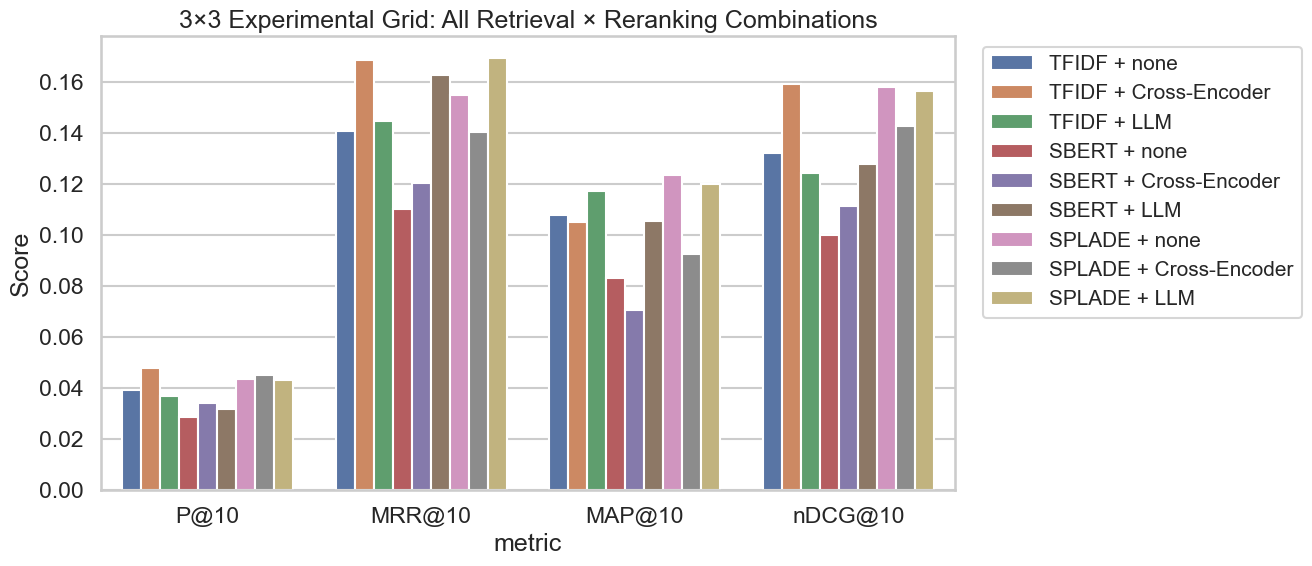

In [16]:
# Build the 3×3 comparison table.

grid_table_rows = []
first_stage_order = ["tfidf", "sbert", "splade"]
second_stage_order = ["", "+ce", "+llm"]

for fs in first_stage_order:
    for ss in second_stage_order:
        label = f"{fs}{ss}"
        if label not in GRID_RESULTS:
            grid_table_rows.append({
                "First Stage": fs.upper(),
                "Second Stage": ss.replace("+ce", "Cross-Encoder").replace("+llm", "LLM") or "—",
                "P@10": float("nan"),
                "MRR@10": float("nan"),
                "MAP@10": float("nan"),
                "nDCG@10": float("nan"),
                "Queries": "—",
                "Runtime (s)": float("nan"),
            })
            continue
        outputs = GRID_RESULTS[label]
        agg = outputs["aggregate_metrics"]
        grid_table_rows.append({
            "First Stage": fs.upper(),
            "Second Stage": ss.replace("+ce", "Cross-Encoder").replace("+llm", "LLM") or "—",
            "P@10": float(agg.loc[0, "precision@10"]) if "precision@10" in agg.columns else float("nan"),
            "MRR@10": float(agg.loc[0, "mrr"]) if "mrr" in agg.columns else float("nan"),
            "MAP@10": float(agg.loc[0, "map"]) if "map" in agg.columns else float("nan"),
            "nDCG@10": float(agg.loc[0, "ndcg@10"]) if "ndcg@10" in agg.columns else float("nan"),
            "Queries": int(agg.loc[0, "query_count"]) if "query_count" in agg.columns else "—",
            "Runtime (s)": float(outputs["runtime_seconds"]),
        })

grid_table = pd.DataFrame(grid_table_rows)
grid_table.to_csv(TABLES_DIR / "grid_3x3_comparison.csv", index=False)
display(grid_table)

# Also save a JSON version for the project summary
grid_summary = {
    "grid_3x3_comparison": grid_table.to_dict(orient="records"),
    "available_combinations": len(GRID_RESULTS),
    "total_combinations": 9,
}
(METRICS_DIR / "grid_3x3_summary.json").write_text(json.dumps(grid_summary, indent=2))

# Bar plot for the grid
plot_frame = grid_table.dropna(subset=["P@10"]).copy()
if not plot_frame.empty:
    plot_frame["label"] = plot_frame["First Stage"] + " + " + plot_frame["Second Stage"].str.replace("—", "none")
    melted = plot_frame.melt(
        id_vars=["label"], value_vars=["P@10", "MRR@10", "MAP@10", "nDCG@10"],
        var_name="metric", value_name="value",
    )
    fig, ax = plt.subplots(figsize=(max(12, len(plot_frame) * 1.5), 6))
    sns.barplot(data=melted, x="metric", y="value", hue="label", ax=ax)
    ax.set_title("3×3 Experimental Grid: All Retrieval × Reranking Combinations")
    ax.set_ylabel("Score")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "grid_3x3_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()


## 7. Fairness audit

In [17]:
from eval.fairness import run_fairness_audit

if RUN_FAIRNESS:
    val_split = load_split("val")
    tfidf_fairness_summary, tfidf_fairness_jobs = run_fairness_audit(val_split, "tfidf")
    sbert_fairness_summary, sbert_fairness_jobs = run_fairness_audit(val_split, "sbert")
    fairness_summary = pd.concat([tfidf_fairness_summary, sbert_fairness_summary], ignore_index=True)
    fairness_summary.to_csv(TABLES_DIR / "fairness_summary.csv", index=False)
    display(fairness_summary)
else:
    fairness_summary = pd.DataFrame()
    print("Fairness audit disabled.")


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.94it/s]


,model,perturbation,top1_change_rate,top10_overlap,mean_spearman,mean_rank_displacement
0,TFIDF,gender_feminine,0.00,1.000,0.999973,0.0112
1,TFIDF,gender_masculine,0.00,1.000,0.999604,0.0752
2,TFIDF,name_white_american,0.04,0.988,0.999624,0.1248
3,TFIDF,name_african_american,0.04,0.992,0.999570,0.1392
4,TFIDF,name_south_asian,0.04,0.996,0.999670,0.1088
5,TFIDF,name_east_asian,0.04,0.996,0.999697,0.1040
6,TFIDF,age_reduced,0.00,0.980,0.995071,0.6704
7,SBERT,gender_feminine,0.00,1.000,0.999969,0.0080
8,SBERT,gender_masculine,0.00,0.988,0.998364,0.3424
9,SBERT,name_white_american,0.36,0.824,0.937902,3.6640


## 8. Runtime breakdown

Runtime captured per pipeline. Stage-1 retrievers ran on the full 823-query test split; stage-2 rerankers (CE, LLM) ran on the matched 100-query stratified subset. Per-query latency is the meaningful operational cost: stage 1 + stage 2 latencies sum to give the deployable end-to-end cost per query.


### 8a. Stage 1 retrievers (full held-out test, 823 queries)


In [18]:
# Stage-1 runtime per retriever.

stage1_rows = []
for label, outputs in [
    ("TF-IDF", tfidf_outputs),
    ("SBERT",  sbert_outputs),
    ("SPLADE", splade_outputs),
    ("FAISS",  faiss_outputs),
]:
    if outputs is None:
        continue
    rt = outputs.get("runtime_seconds", float("nan"))
    qc = int(outputs["aggregate_metrics"].loc[0, "query_count"])
    rt_f = float(rt) if rt is not None and not pd.isna(rt) else float("nan")
    s_per_q = rt_f / max(qc, 1) if not pd.isna(rt_f) else float("nan")
    stage1_rows.append({
        "model": label,
        "queries": qc,
        "runtime_s": round(rt_f, 2),
        "s_per_query": round(s_per_q, 4),
    })

stage1_runtime = pd.DataFrame(stage1_rows)
stage1_runtime.to_csv(TABLES_DIR / "runtime_stage1.csv", index=False)
display(stage1_runtime)


,model,queries,runtime_s,s_per_query
0,TF-IDF,823,2.04,0.0025
1,SBERT,823,15.16,0.0184
2,SPLADE,823,491.05,0.5967
3,FAISS,823,13.73,0.0167


### 8b. Stage 1 + Stage 2 pipelines (matched 100-query subset)

For each `(first stage, reranker)` combination: stage 1's measured wall-clock (full 823 queries) and stage 2's wall-clock on the matched 100-query subset, plus per-query latencies. `total_s_per_query` is the operational end-to-end cost — what a deployed pipeline pays per incoming query.


In [19]:
# Stage 1 + Stage 2 pipeline runtime breakdown.

pipeline_rows = []
for fs_label, fs_key in [("TF-IDF", "tfidf"), ("SBERT", "sbert"), ("SPLADE", "splade")]:
    fs_outputs = GRID_RESULTS.get(fs_key)
    if fs_outputs is None:
        continue
    fs_rt = float(fs_outputs.get("runtime_seconds", float("nan")))
    fs_qc = int(fs_outputs["aggregate_metrics"].loc[0, "query_count"])
    fs_per_q = fs_rt / max(fs_qc, 1) if not pd.isna(fs_rt) else float("nan")

    for ss_label, ss_key in [("CE", "ce"), ("LLM", "llm")]:
        grid_key = f"{fs_key}+{ss_key}"
        ss_outputs = GRID_RESULTS.get(grid_key)
        if ss_outputs is None:
            continue
        ss_rt = float(ss_outputs.get("runtime_seconds", float("nan")))
        ss_qc = int(ss_outputs["aggregate_metrics"].loc[0, "query_count"])
        ss_per_q = ss_rt / max(ss_qc, 1) if not pd.isna(ss_rt) else float("nan")
        total_per_q = (fs_per_q + ss_per_q) if not (pd.isna(fs_per_q) or pd.isna(ss_per_q)) else float("nan")

        pipeline_rows.append({
            "pipeline": f"{fs_label} -> {ss_label}",
            "stage1_runtime_s": round(fs_rt, 2),
            "stage1_queries": fs_qc,
            "stage1_s_per_query": round(fs_per_q, 4),
            "stage2_runtime_s": round(ss_rt, 2),
            "stage2_queries": ss_qc,
            "stage2_s_per_query": round(ss_per_q, 4),
            "total_s_per_query": round(total_per_q, 4),
        })

pipeline_runtime = pd.DataFrame(pipeline_rows)
pipeline_runtime.to_csv(TABLES_DIR / "runtime_stage1_plus_stage2.csv", index=False)
display(pipeline_runtime)


,pipeline,stage1_runtime_s,stage1_queries,stage1_s_per_query,stage2_runtime_s,stage2_queries,stage2_s_per_query,total_s_per_query
0,TF-IDF -> CE,2.04,823,0.0025,1108.77,100,11.0877,11.0902
1,TF-IDF -> LLM,2.04,823,0.0025,3555.26,100,35.5526,35.5551
2,SBERT -> CE,15.16,823,0.0184,1131.31,100,11.3131,11.3315
3,SBERT -> LLM,15.16,823,0.0184,3420.15,100,34.2015,34.2199
4,SPLADE -> CE,491.05,823,0.5967,925.73,100,9.2573,9.8540
5,SPLADE -> LLM,491.05,823,0.5967,3776.18,100,37.7618,38.3584
